In [43]:
library(Seurat)
library(tidyverse)
library(presto)
library(glmGamPoi)
library(future)
library(SeuratObject)
library(viridis)
# library(ggpubr)
library(scales)
library(presto)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(purrr)
library(tidyr)

Warning message:
“package ‘viridis’ was built under R version 4.4.3”
Loading required package: viridisLite

Warning message:
“package ‘viridisLite’ was built under R version 4.4.3”


Warning message:
“package ‘scales’ was built under R version 4.4.3”

Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




clusterProfiler v4.14.6 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan,
X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal
enrichment tool for interpreting omics data. The Innovation. 2021,
2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:purrr’:

    simplify


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from 

In [ ]:
# Load Harmony integrated object
harmony_obj <- readRDS('/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/01_harmony/orig.ident/obj/harmony_integrated_orig.ident.rds')
harmony_obj
harmony_obj@meta.data |> head(2)

# Load RPCA integrated object
rpca_obj <- readRDS('/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/02_rpca/orig.ident/obj/rpca_integrated_orig.ident.rds')
rpca_obj
rpca_obj@meta.data |> head(2)

An object of class Seurat 
74475 features across 302646 samples within 2 assays 
Active assay: SCT (35869 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.1,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.119632,singlet,⋯,3,3,1,10,41,31,29,45,54,54
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.780499,singlet,⋯,2,26,29,36,32,33,39,37,39,39


An object of class Seurat 
74475 features across 302646 samples within 2 assays 
Active assay: SCT (35869 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap, rpca, umap.rpca

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.1,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.119632,singlet,⋯,6,6,20,19,18,22,17,13,11,11
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.780499,singlet,⋯,1,3,17,12,23,18,29,27,32,32


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



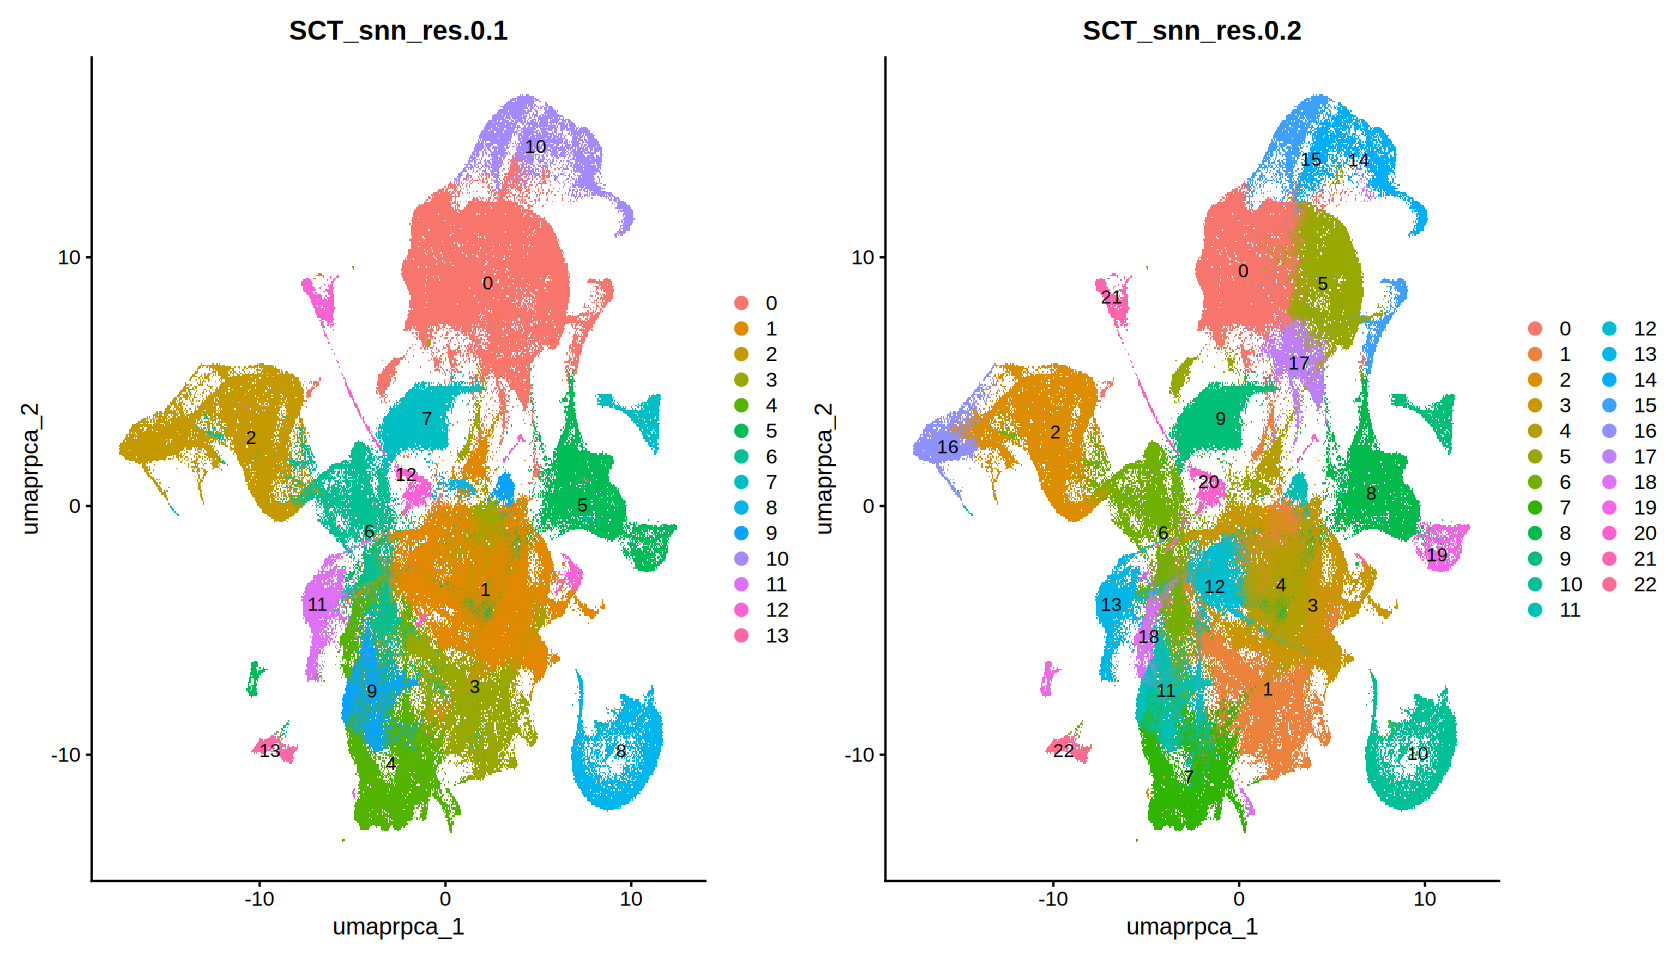

In [60]:
options(repr.plot.width = 14, repr.plot.height = 8)
p1 <- DimPlot(rpca_obj, reduction = 'umap.rpca', group.by = 'SCT_snn_res.0.1', label = TRUE)
p2 <- DimPlot(rpca_obj, reduction = 'umap.rpca', group.by = 'SCT_snn_res.0.2', label = TRUE)

p1 + p2 

In [4]:
harmony_obj <- PrepSCTFindMarkers(harmony_obj, assay = "SCT", verbose = TRUE)
rpca_obj <- PrepSCTFindMarkers(rpca_obj, assay = "SCT", verbose = TRUE)

Found 9 SCT models. Recorrecting SCT counts using minimum median counts: 1874



Found 9 SCT models. Recorrecting SCT counts using minimum median counts: 1874



In [6]:
# Marker for Harmony
Idents(harmony_obj) <- 'SCT_snn_res.0.08'

harmony_markers <- FindAllMarkers(harmony_obj,
                              assay = "SCT",
                              only.pos = TRUE,
                              min.pct = 0.25, 
                              logfc.threshold = 0.25,
                              test.use = "wilcox")

# Marker for RPCA
# 0.1 resolution 
Idents(rpca_obj) <- 'SCT_snn_res.0.1'

rpca_markers_0.1 <- FindAllMarkers(rpca_obj,
                              assay = "SCT",
                              only.pos = TRUE,
                              min.pct = 0.25,
                              logfc.threshold = 0.25,
                              test.use = "wilcox")
# 0.2 resolution
Idents(rpca_obj) <- 'SCT_snn_res.0.2'

rpca_markers_0.2 <- FindAllMarkers(rpca_obj,
                              assay = "SCT",
                              only.pos = TRUE,
                              min.pct = 0.25,
                              logfc.threshold = 0.25,

                              test.use = "wilcox")                            

Calculating cluster 0

Calculating cluster 1

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 2

Calculating cluster 20

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster

In [7]:
# Arrange by avg_log2FC
harmony_markers <- harmony_markers |> arrange(desc(avg_log2FC))
rpca_markers_0.1 <- rpca_markers_0.1 |> arrange(desc(avg_log2FC))
rpca_markers_0.2 <- rpca_markers_0.2 |> arrange(desc(avg_log2FC))

# Save markers in the csv format 
write.csv(harmony_markers, file = '/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/01_harmony/orig.ident/markers/harmony_markers.csv')
write.csv(rpca_markers_0.1, file = '/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/02_rpca/orig.ident/markers/rpca_markers_0.1.csv')
write.csv(rpca_markers_0.2, file = '/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/02_rpca/orig.ident/markers/rpca_markers_0.2.csv')

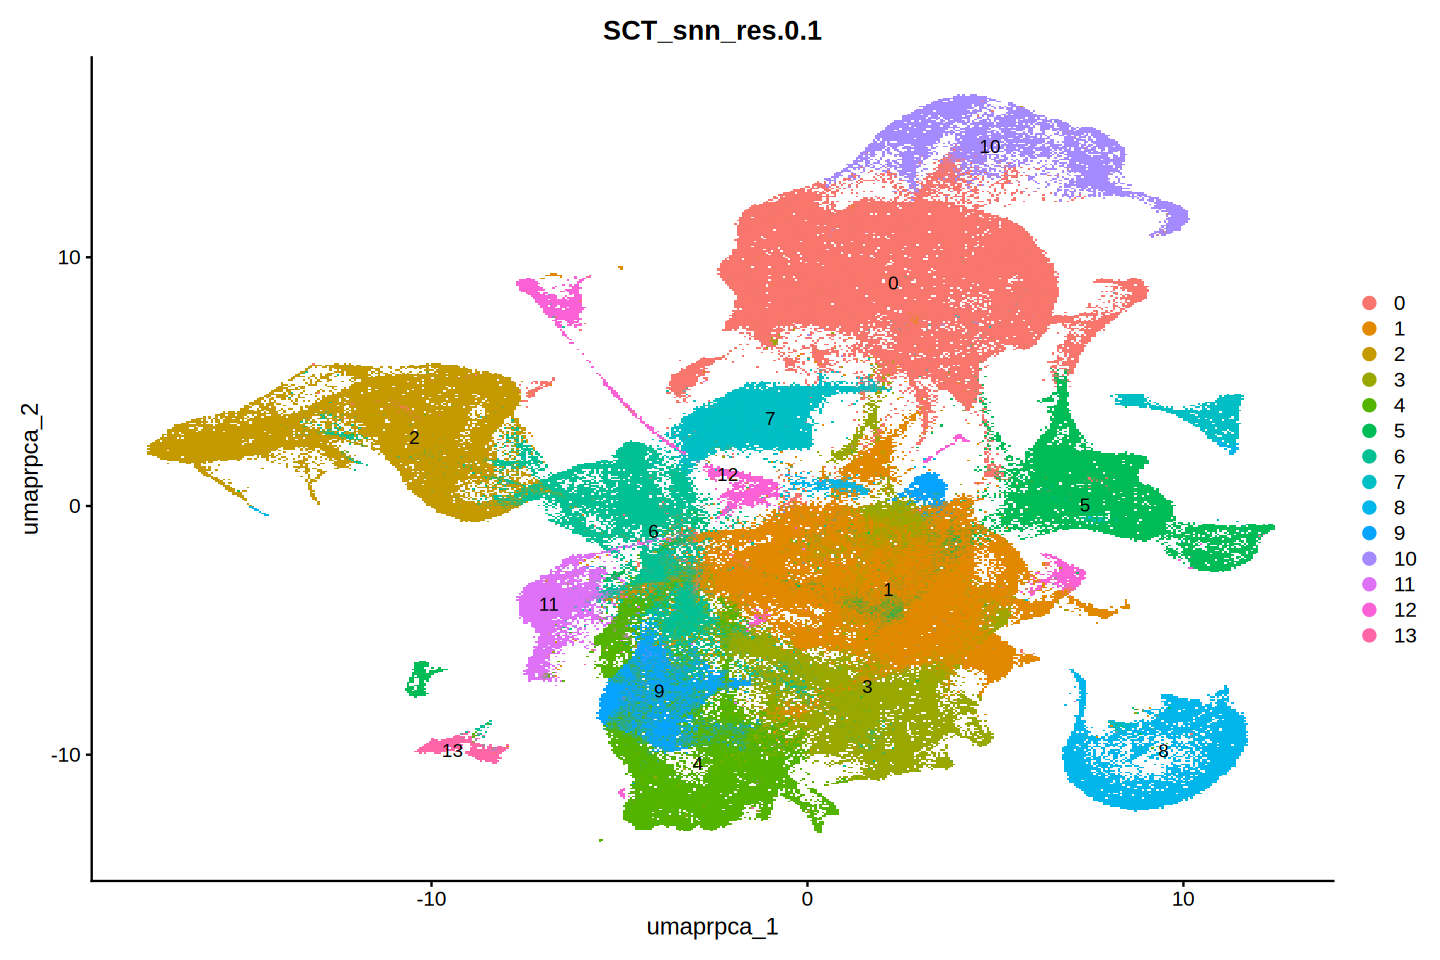

In [27]:
p2

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



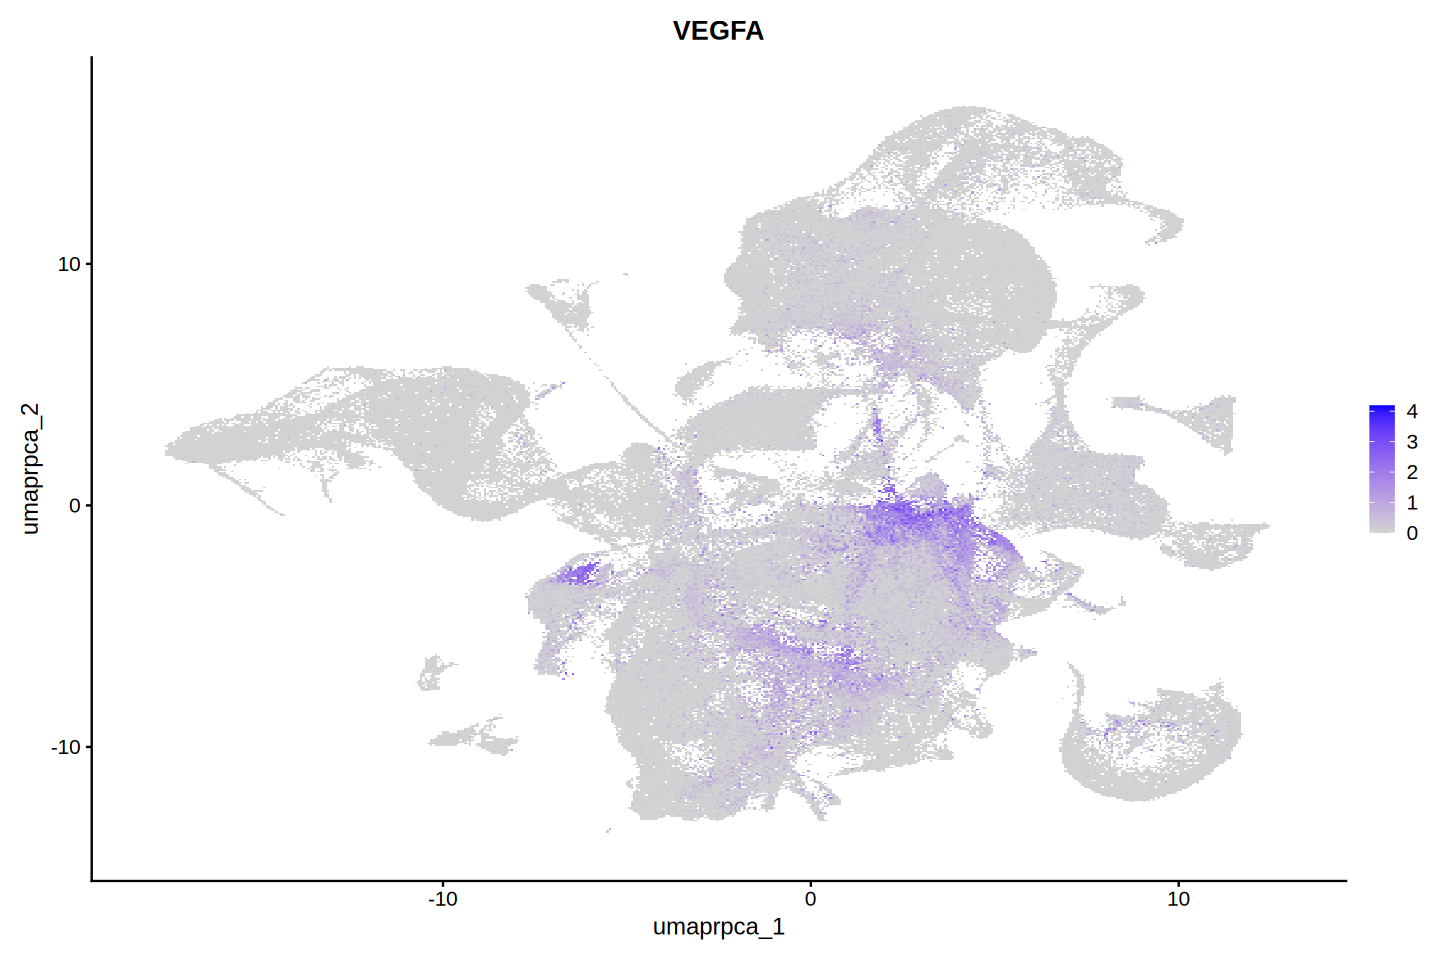

In [26]:
options(repr.plot.width = 12, repr.plot.height = 8)
FeaturePlot(rpca_obj, features = c('VEGFA'), reduction = 'umap.rpca', ncol = 1)

In [ ]:
# Marker for harmony
cluster0 <- harmony_markers %>% filter(cluster == 0) %>% arrange(desc(avg_log2FC))
cluster1 <- harmony_markers %>% filter(cluster == 1) %>% arrange(desc(avg_log2FC))
cluster2 <- harmony_markers %>% filter(cluster == 2) %>% arrange(desc(avg_log2FC))
cluster3 <- harmony_markers %>% filter(cluster == 3) %>% arrange(desc(avg_log2FC))
cluster4 <- harmony_markers %>% filter(cluster == 4) %>% arrange(desc(avg_log2FC))
cluster5 <- harmony_markers %>% filter(cluster == 5) %>% arrange(desc(avg_log2FC))
cluster6 <- harmony_markers %>% filter(cluster == 6) %>% arrange(desc(avg_log2FC))
cluster7 <- harmony_markers %>% filter(cluster == 7) %>% arrange(desc(avg_log2FC))
cluster8 <- harmony_markers %>% filter(cluster == 8) %>% arrange(desc(avg_log2FC))
cluster9 <- harmony_markers %>% filter(cluster == 9) %>% arrange(desc(avg_log2FC))
cluster10 <- harmony_markers %>% filter(cluster == 10) %>% arrange(desc(avg_log2FC))
cluster11 <- harmony_markers %>% filter(cluster == 11) %>% arrange(desc(avg_log2FC))
cluster12 <- harmony_markers %>% filter(cluster == 12) %>% arrange(desc(avg_log2FC))
cluster13 <- harmony_markers %>% filter(cluster == 13) %>% arrange(desc(avg_log2FC))
cluster14 <- harmony_markers %>% filter(cluster == 14) %>% arrange(desc(avg_log2FC))
cluster15 <- harmony_markers %>% filter(cluster == 15) %>% arrange(desc(avg_log2FC))
cluster16 <- harmony_markers %>% filter(cluster == 16) %>% arrange(desc(avg_log2FC))
cluster17 <- harmony_markers %>% filter(cluster == 17) %>% arrange(desc(avg_log2FC))
cluster18 <- harmony_markers %>% filter(cluster == 18) %>% arrange(desc(avg_log2FC))
cluster19 <- harmony_markers %>% filter(cluster == 19) %>% arrange(desc(avg_log2FC))
cluster20 <- harmony_markers %>% filter(cluster == 20) %>% arrange(desc(avg_log2FC))

In [63]:
# Range
# top_markers <- cluster1$gene[1:15]
# top_markers <- c('TMEM119', 'TREM2', 'P2RY12', "CX3CR1", "GPR34", "SALL1", "CSF1R")
top_markers <- c('SLC4A4', 'RGS6', 'GFAP', "PEG10", "RFX4")
# top_markers <- c("APC", "CNTNAP2", "CNP", "MAG", "MBP", "MOG", "PLP1", "RTN4", "OMG", "TPPP")


# Flatten the markers for DotPlot
markers_genes <- unlist(top_markers)
markers_genes <- make.unique(markers_genes)

# Set factor levels in the order of your original markers vector
markers_genes <- factor(markers_genes, levels = markers_genes)

# Create a mapping from gene -> "Cluster0:Gene" label
label_map <- setNames(
  paste0("ClusterX:", markers_genes),
  markers_genes
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


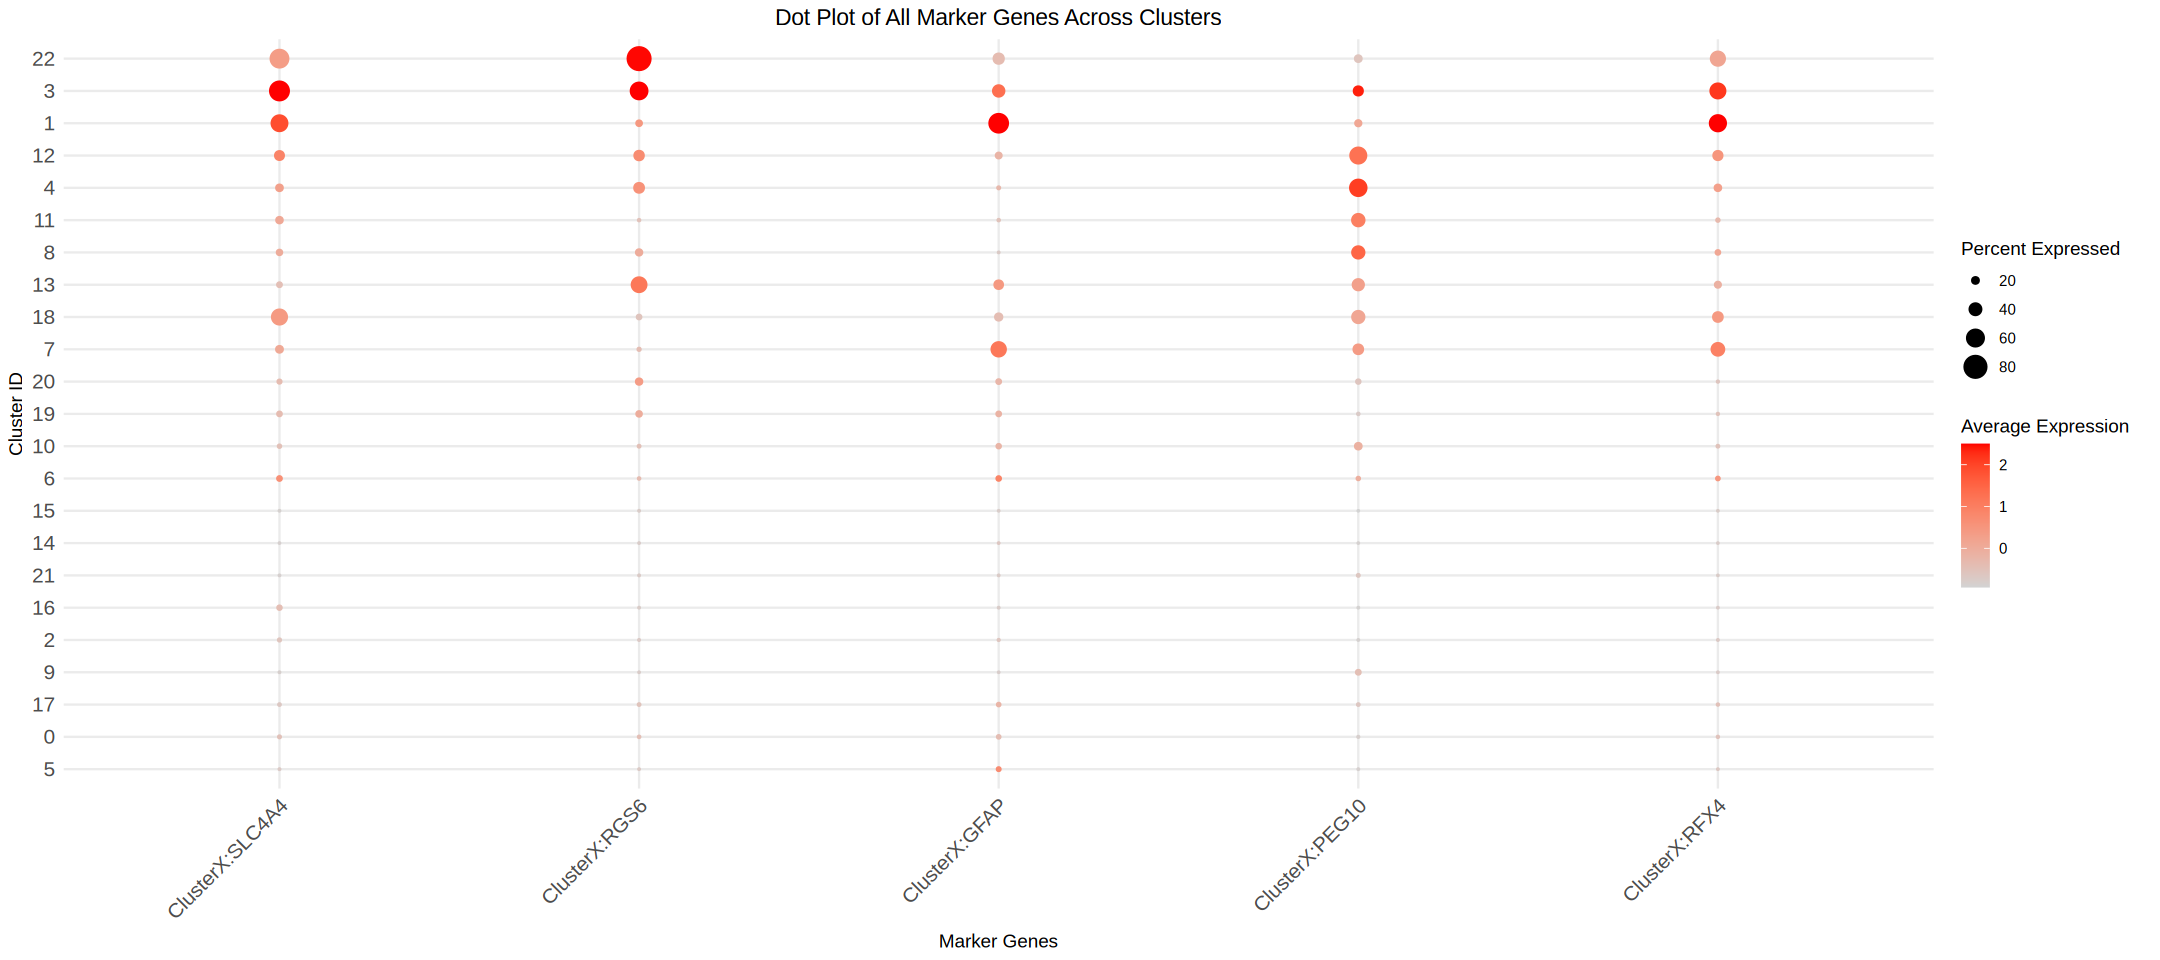

In [65]:
options(repr.plot.width = 18, repr.plot.height = 8)
Idents(rpca_obj) <- 'SCT_snn_res.0.2' # Ensure the correct cluster identities are set
DotPlot(rpca_obj, features = markers_genes, cluster.idents = TRUE) +
  scale_color_gradient(low = "lightgrey", high = "red") +
  theme_minimal() +
  xlab("Marker Genes") +
  ylab("Cluster ID") +
  ggtitle("Dot Plot of All Marker Genes Across Clusters") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    plot.title  = element_text(hjust = 0.5)
  ) +
  # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
  scale_x_discrete(labels = label_map)

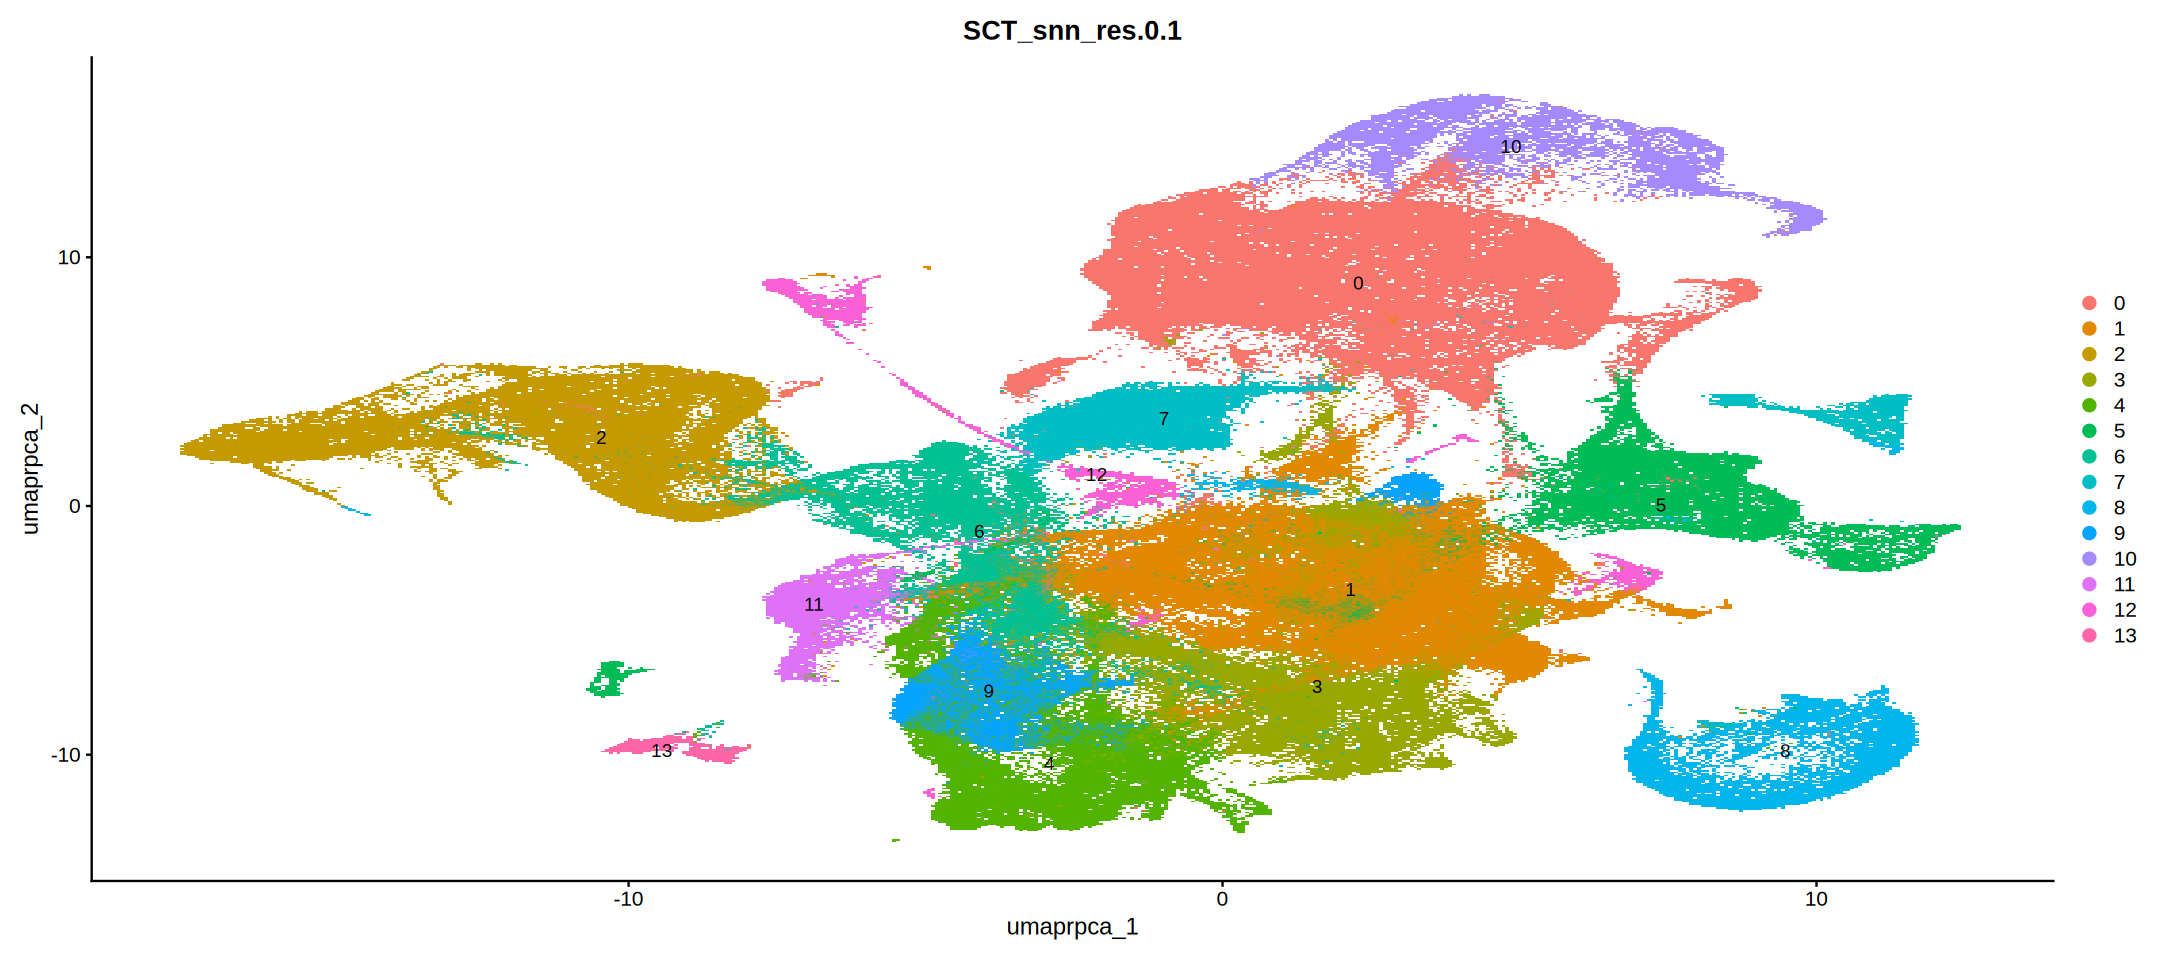

In [30]:
p2

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



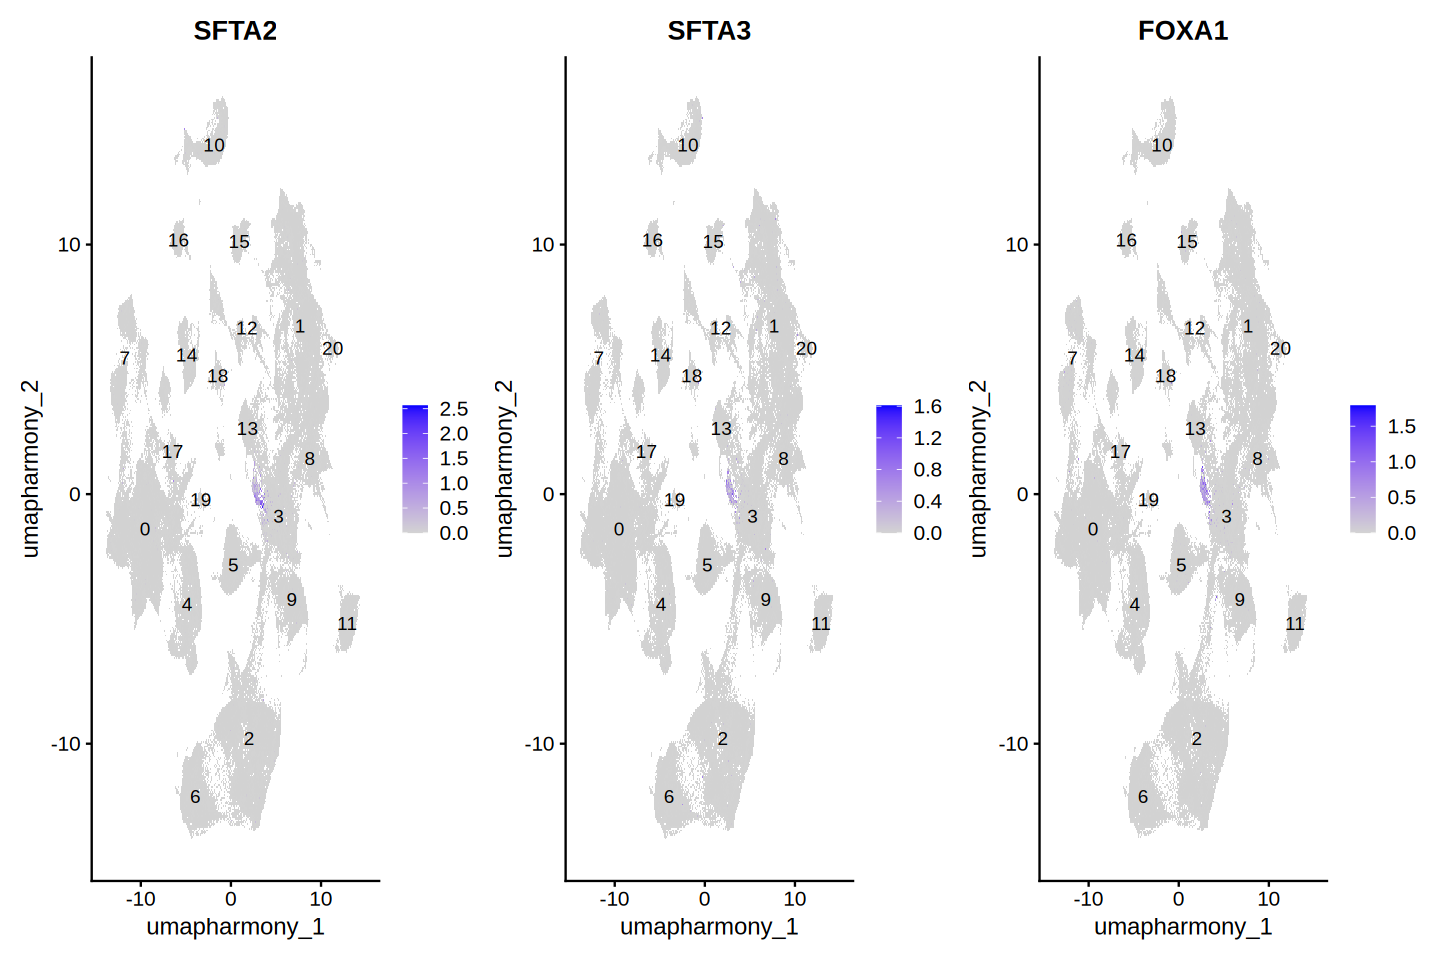

In [79]:
Idents(obj) <- "SCT_snn_res.0.08"
options (repr.plot.width = 12, repr.plot.height = 8)
# Create feature plots with custom settings
FeaturePlot(obj,
            features = c("SFTA2", 'SFTA3', "FOXA1"),
            reduction = "umap.harmony",
            ncol = 3, label = TRUE)

# GO Pathway

In [41]:
cluster0_genes <- rpca_markers_0.1 |> filter(cluster == 0 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster1_genes <- rpca_markers_0.1 |> filter(cluster == 1 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster2_genes <- rpca_markers_0.1 |> filter(cluster == 2 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster3_genes <- rpca_markers_0.1 |> filter(cluster == 3 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster4_genes <- rpca_markers_0.1 |> filter(cluster == 4 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster5_genes <- rpca_markers_0.1 |> filter(cluster == 5 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster6_genes <- rpca_markers_0.1 |> filter(cluster == 6 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster7_genes <- rpca_markers_0.1 |> filter(cluster == 7 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster8_genes <- rpca_markers_0.1 |> filter(cluster == 8 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster9_genes <- rpca_markers_0.1 |> filter(cluster == 9 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster10_genes <- rpca_markers_0.1 |> filter(cluster == 10 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster11_genes <- rpca_markers_0.1 |> filter(cluster == 11 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster12_genes <- rpca_markers_0.1 |> filter(cluster == 12 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster13_genes <- rpca_markers_0.1 |> filter(cluster == 13 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)

In [54]:
# Convert gene symbols to Entrez IDs
entrez_ids <- bitr(
    cluster5_genes,
    fromType = "SYMBOL", 
    toType = "ENTREZID", 
    OrgDb = org.Hs.eg.db)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(cluster5_genes, fromType = "SYMBOL", toType = "ENTREZID", :
“0.28% of input gene IDs are fail to map...”


In [55]:
# GO enrichment analysis
go_result <- enrichGO(gene = entrez_ids$ENTREZID,
                                         OrgDb = org.Hs.eg.db,
                                         ont = "BP",  # Biological Process
                                         pAdjustMethod = "BH",
                                         pvalueCutoff = 0.05,
                                         qvalueCutoff = 0.05
                                         )

Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


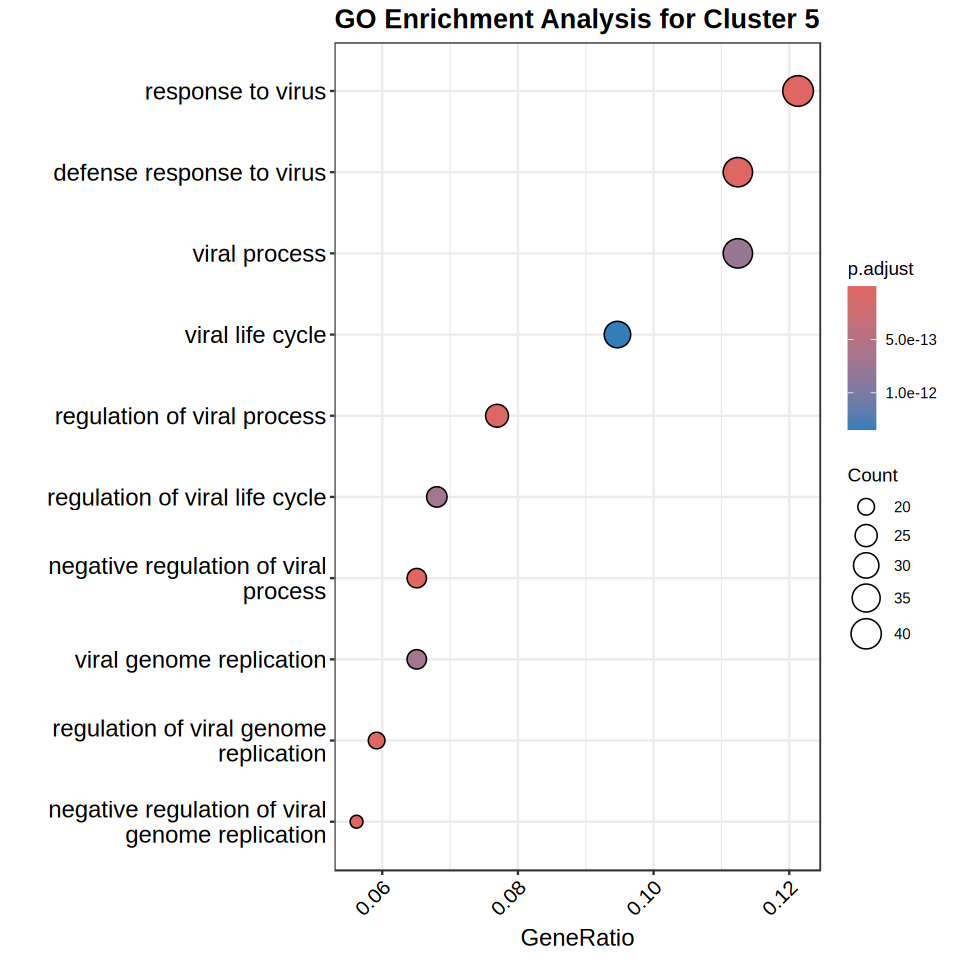

In [56]:
# Visualize GO results
options(repr.plot.width = 8, repr.plot.height = 8)
dotplot(go_result, showCategory = 10) + 
    ggtitle("GO Enrichment Analysis for Cluster 5") +
    theme(plot.title = element_text(size = 16, face = "bold"),
          axis.text.y = element_text(size = 14),
          axis.text.x = element_text(size = 12, angle = 45, hjust = 1),
          axis.title = element_text(size = 14)) +
    scale_size(range = c(3, 8))

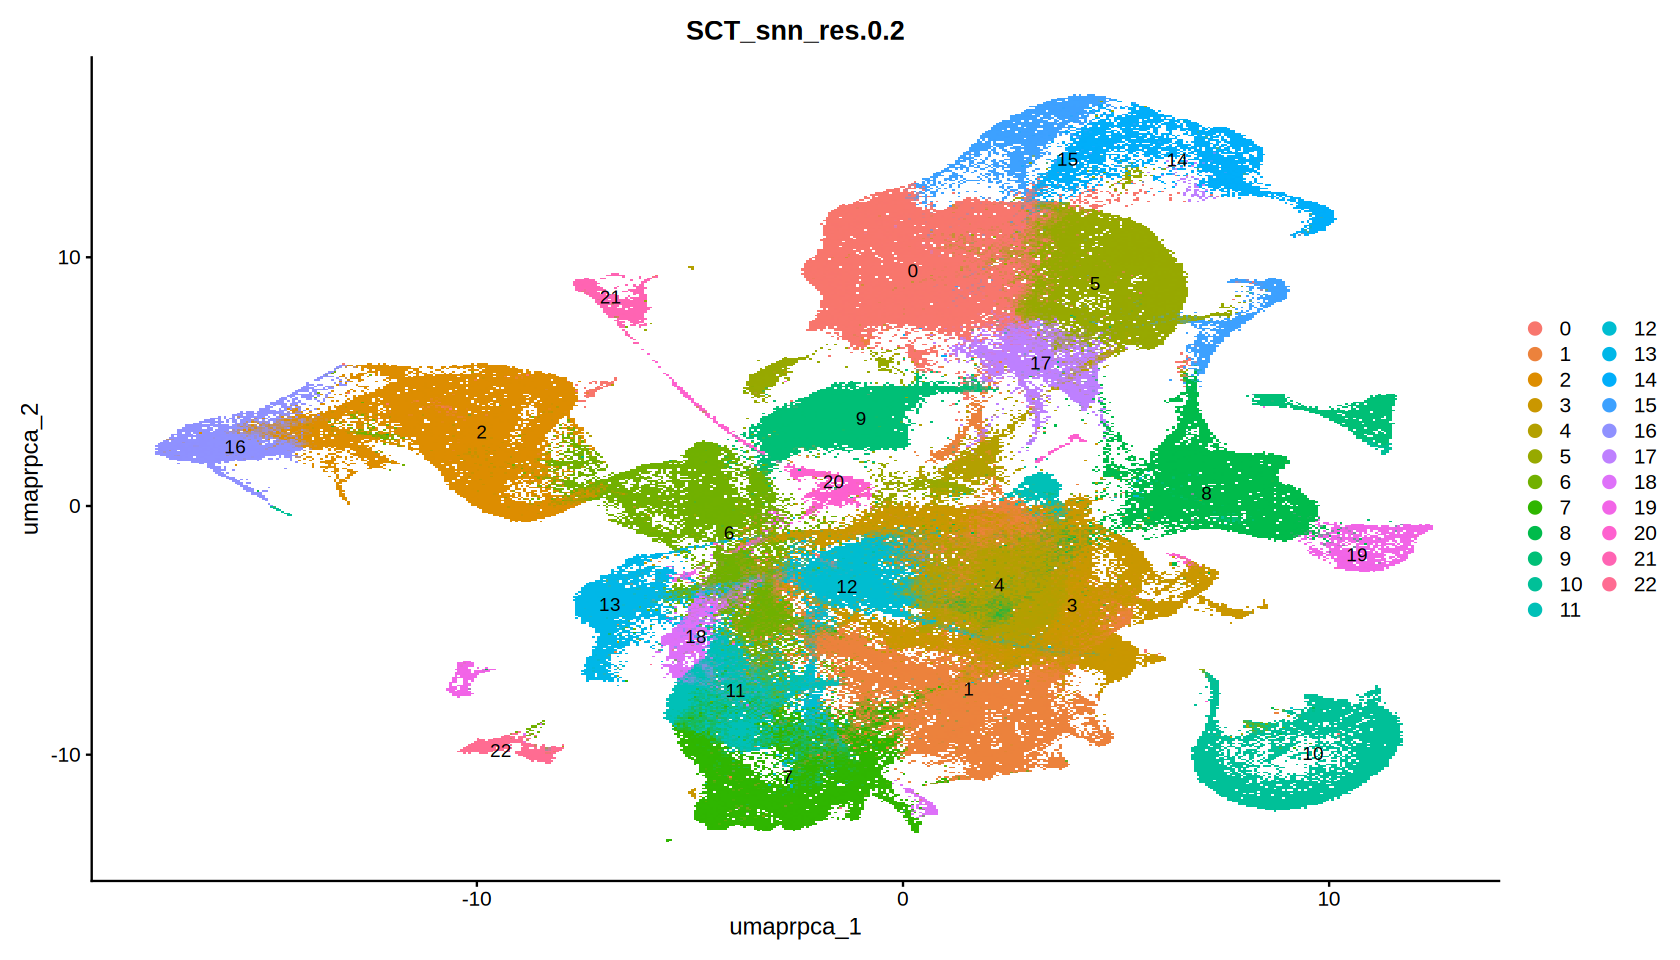

In [61]:
p2

In [ ]:
# Resolution 0.2:

# 0, 5, 8, 15, 14, 17: Myeloid 
# 1: Astrocyte-like 
# 2, 16: TILs => Double check with 6 
# 3:Mature_Astrocytes
# 4: MES-like 
# 9: CTAs
# 10: Mature_Oligodendrocytes
# 12: Proliferating Tumor Cells
# 13: Oligodendrocyte Progenitor Like Cells (OPC like)
# 18: Neural Progenitor Like Cells (NPC like)
# 19: Endothelial => CHECK
# 20: Pericytes
# 21: B cells
# 22: Excitatory Neurons (Glutamatergic Neurons)